In [1]:
import pandas as pd

# Load the datasets
sales_data = pd.read_csv('/kaggle/input/e-commerece-sales-data-2024/E-commerece sales data 2024.csv')
customer_details = pd.read_csv('/kaggle/input/e-commerece-sales-data-2024/customer_details.csv')
product_details = pd.read_csv('/kaggle/input/e-commerece-sales-data-2024/product_details.csv')

# Display the first few rows of each dataset to verify loading
print("Sales Data:")
print(sales_data.head())
print("\nCustomer Details:")
print(customer_details.head())
print("\nProduct Details:")
print(product_details.head())


Sales Data:
   user id                        product id Interaction type  \
0      1.0  4c69b61db1fc16e7013b43fc926e502d         purchase   
1      2.0  66d49bbed043f5be260fa9f7fbff5957             view   
2      3.0  2c55cae269aebf53838484b0d7dd931a             like   
3      4.0  18018b6bc416dab347b1b7db79994afa             view   
4      5.0  e04b990e95bf73bbe6a3fa09785d7cd0             like   

        Time stamp  Unnamed: 4  
0  10/10/2023 8:00         NaN  
1  11/10/2023 8:00         NaN  
2  12/10/2023 8:00         NaN  
3  13/10/2023 8:00         NaN  
4  14/10/2023 8:00         NaN  

Customer Details:
   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                 

In [2]:
# drop columns with 100% missing values and display the shape droped columns name
print("\n Sales Columns with 100% missing values: ", sales_data.columns[sales_data.isnull().all()])
sales_data.dropna(axis=1, how='all', inplace=True)

# drop columns with 100% missing values and display the shape droped columns name
print("\n Customer Details Columns with 100% missing values: ", customer_details.columns[customer_details.isnull().all()])
customer_details.dropna(axis=1, how='all', inplace=True)

# drop columns with 100% missing values and display the shape droped columns name
print("\n Product Details Columns with 100% missing values: ", product_details.columns[product_details.isnull().all()])
product_details.dropna(axis=1, how='all', inplace=True)



 Sales Columns with 100% missing values:  Index(['Unnamed: 4'], dtype='object')

 Customer Details Columns with 100% missing values:  Index([], dtype='object')

 Product Details Columns with 100% missing values:  Index(['Brand Name', 'Asin', 'List Price', 'Quantity', 'Sku', 'Stock',
       'Product Details', 'Dimensions', 'Color', 'Ingredients',
       'Direction To Use', 'Size Quantity Variant', 'Product Description'],
      dtype='object')


In [3]:
import numpy as np

# Checking for missing values in each dataset
sales_missing = sales_data.isnull().sum()
customer_missing = customer_details.isnull().sum()
product_missing = product_details.isnull().sum()

# For customer_details, fill missing numeric values with the mean and categorical values with the mode
for column in customer_details.columns:
    if customer_details[column].dtype == 'object':
        customer_details[column].fillna(customer_details[column].mode()[0], inplace=True)
    else:
        customer_details[column].fillna(customer_details[column].mean(), inplace=True)

# For product_details, assuming missing values in 'List Price' and other numeric fields, fill with mean
# and categorical fields with mode
for column in product_details.columns:
    if product_details[column].dtype == 'object':
        product_details[column].fillna(product_details[column].mode()[0], inplace=True)
    else:
        product_details[column].fillna(product_details[column].mean(), inplace=True)

# Summarizing key statistics for numerical and categorical variables
sales_summary = sales_data.describe(include=[np.number])
customer_summary = customer_details.describe(include=[np.number])

sales_cat_summary = sales_data.describe(include=[object])
customer_cat_summary = customer_details.describe(include=[object])
product_cat_summary = product_details.describe(include=[object])

# Displaying summaries
print("Sales Data Summary (Numerical):")
print(sales_summary)
print("\nSales Data Summary (Categorical):")
print(sales_cat_summary)

print("\nCustomer Details Summary (Numerical):")
print(customer_summary)
print("\nCustomer Details Summary (Categorical):")
print(customer_cat_summary)


/tmp/ipykernel_18/3483301099.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_details[column].fillna(customer_details[column].mean(), inplace=True)
/tmp/ipykernel_18/3483301099.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

Sales Data Summary (Numerical):
           user id
count  2999.000000
mean   1500.000000
std     865.881054
min       1.000000
25%     750.500000
50%    1500.000000
75%    2249.500000
max    2999.000000

Sales Data Summary (Categorical):
                              product id Interaction type       Time stamp
count                               2999             2871             2999
unique                              2999                3              366
top     4c69b61db1fc16e7013b43fc926e502d             like  10/10/2023 8:00
freq                                   1             1145               21

Customer Details Summary (Numerical):
       Customer ID          Age  Purchase Amount (USD)  Review Rating  \
count  3900.000000  3900.000000            3900.000000    3900.000000   
mean   1950.500000    44.068462              59.764359       3.749949   
std    1125.977353    15.207589              23.685392       0.716223   
min       1.000000    18.000000              20.000000  

In [4]:
# check for missing values 
print("\n Sales Data Missing Values: ", sales_data.isnull().sum())
print("\n Product Details Missing Values: ", product_details.isnull().sum())
print("\n Customer Details Missing Values: ", customer_details.isnull().sum())



 Sales Data Missing Values:  user id             295
product id          295
Interaction type    423
Time stamp          295
dtype: int64

 Product Details Missing Values:  Uniqe Id                 0
Product Name             0
Category                 0
Upc Ean Code             0
Selling Price            0
Model Number             0
About Product            0
Product Specification    0
Technical Details        0
Shipping Weight          0
Product Dimensions       0
Image                    0
Variants                 0
Product Url              0
Is Amazon Seller         0
dtype: int64

 Customer Details Missing Values:  Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount

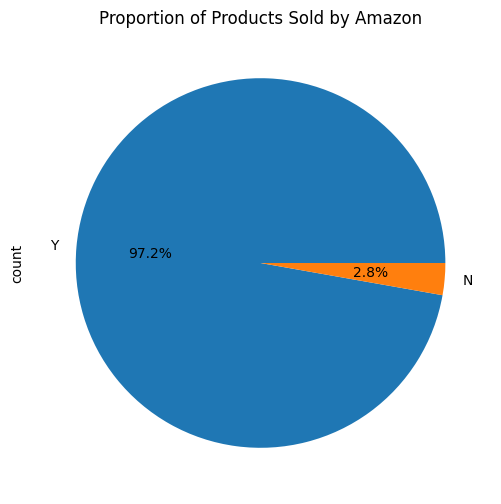

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
product_details['Is Amazon Seller'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Proportion of Products Sold by Amazon')
plt.show()


In [6]:
# relation ship between sales_data and customer_details
sales_customer = pd.merge(sales_data, customer_details, left_on='user id', right_on='Customer ID', how='inner')

# merge sales_customer and product_details
sales_customer_product = pd.merge(sales_customer, product_details, left_on='product id', right_on='Uniqe Id', how='inner')

# Display columns in the merged DataFrame
print("Columns in sales_customer_product DataFrame: ", sales_customer_product.columns)


Columns in sales_customer_product DataFrame:  Index(['user id', 'product id', 'Interaction type', 'Time stamp',
       'Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category_x',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases', 'Uniqe Id', 'Product Name',
       'Category_y', 'Upc Ean Code', 'Selling Price', 'Model Number',
       'About Product', 'Product Specification', 'Technical Details',
       'Shipping Weight', 'Product Dimensions', 'Image', 'Variants',
       'Product Url', 'Is Amazon Seller'],
      dtype='object')


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

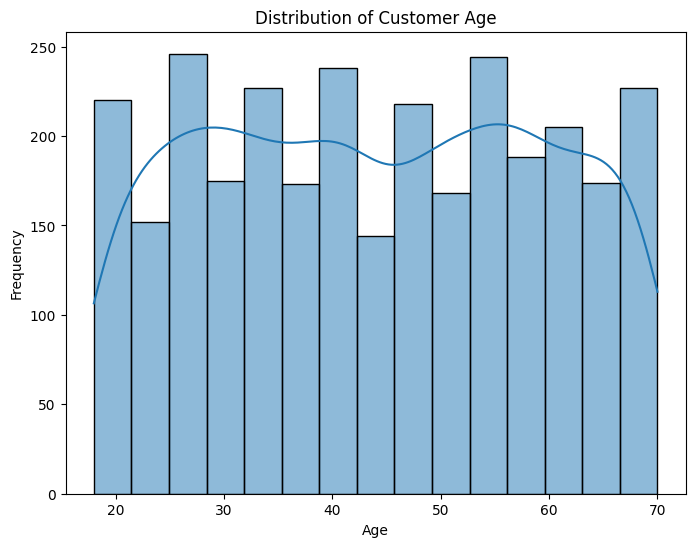

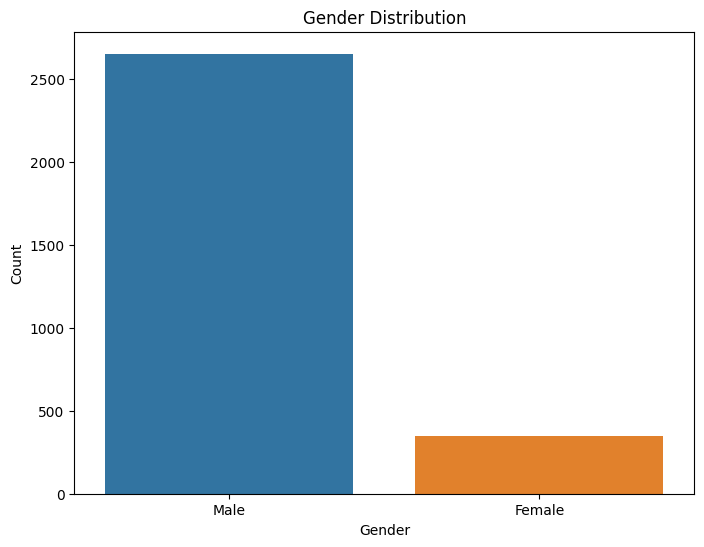

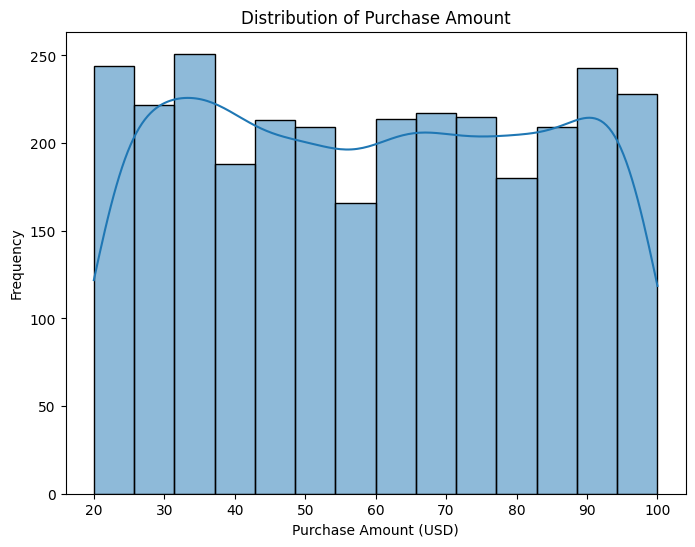

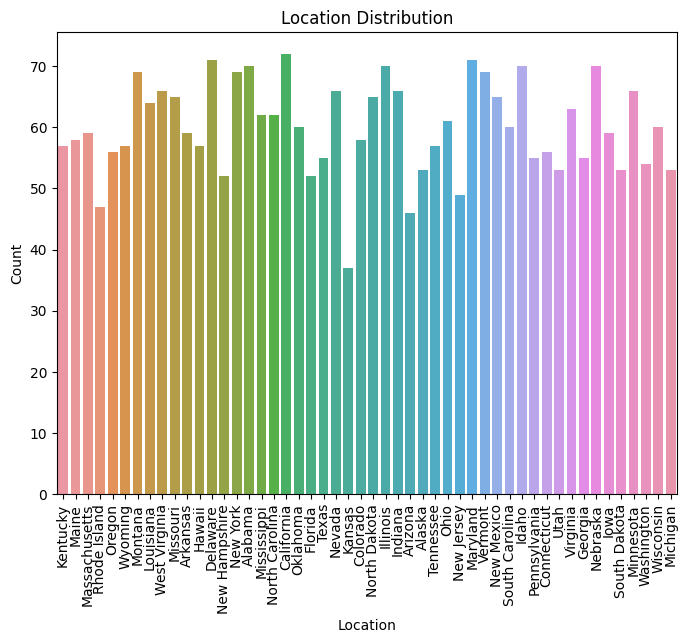

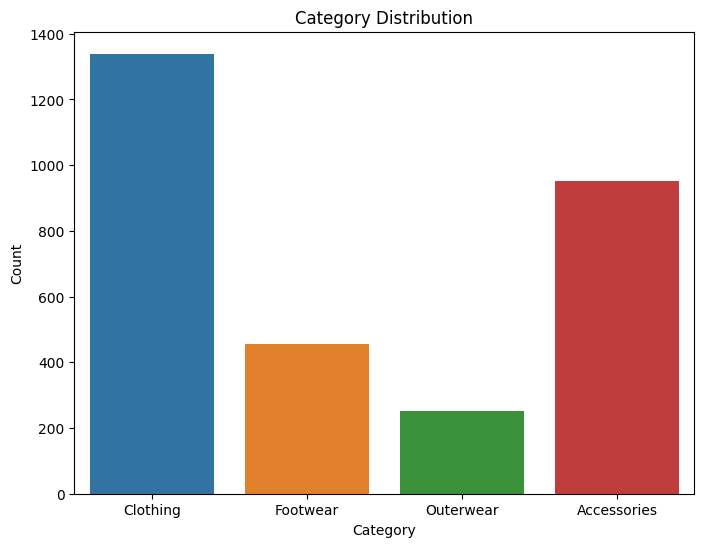

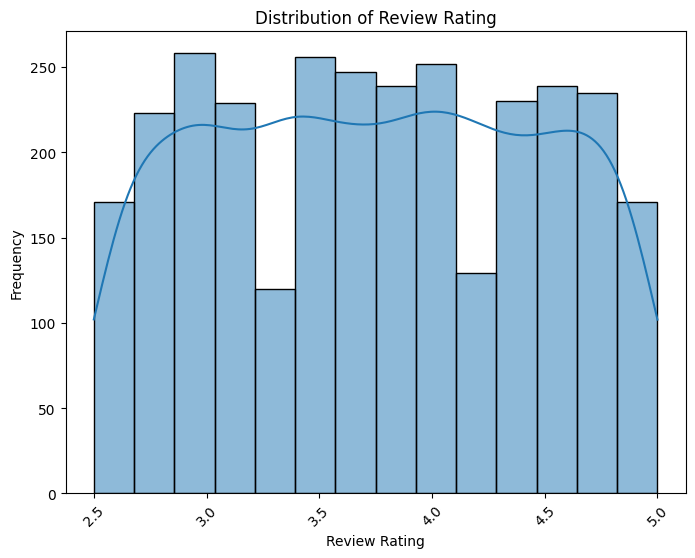

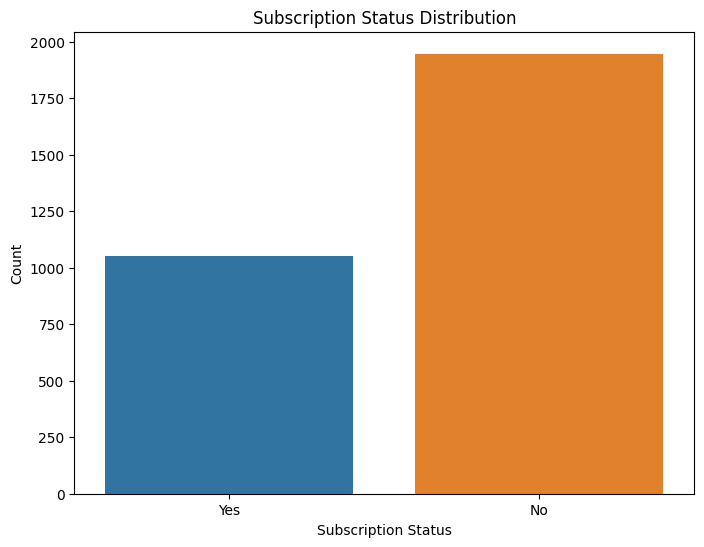

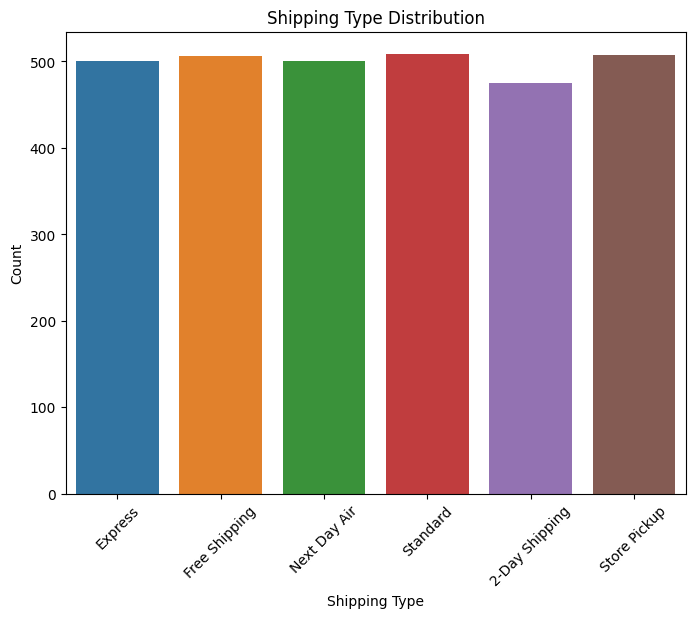

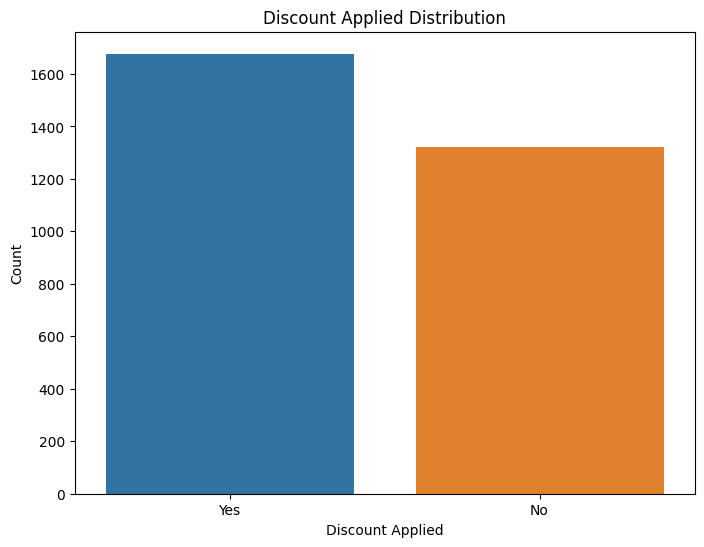

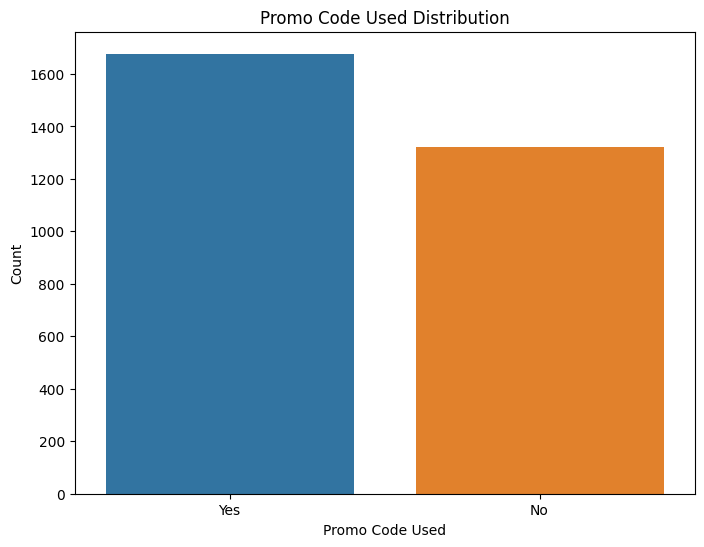

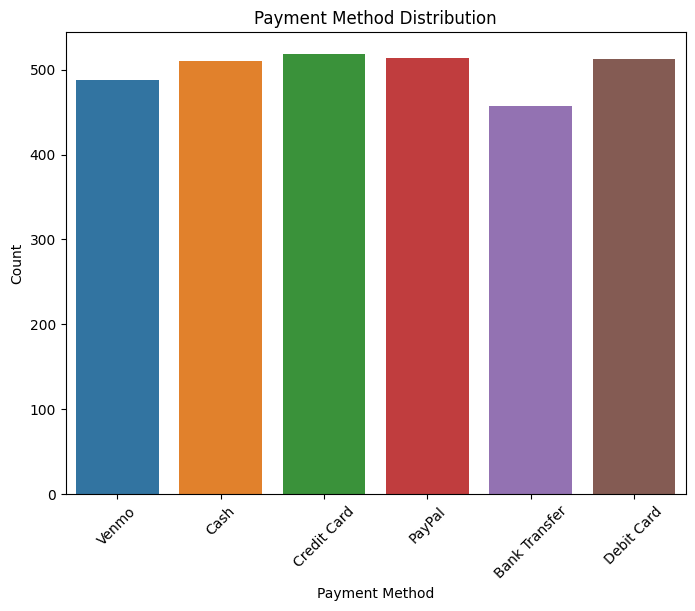

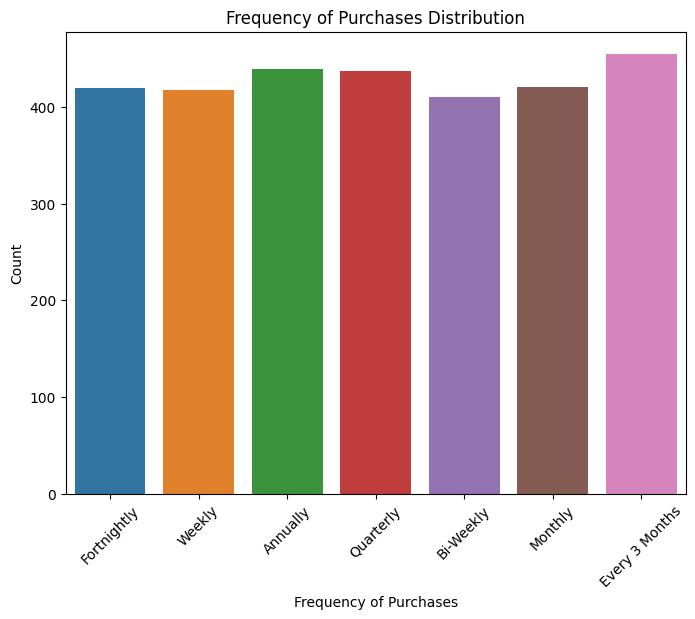

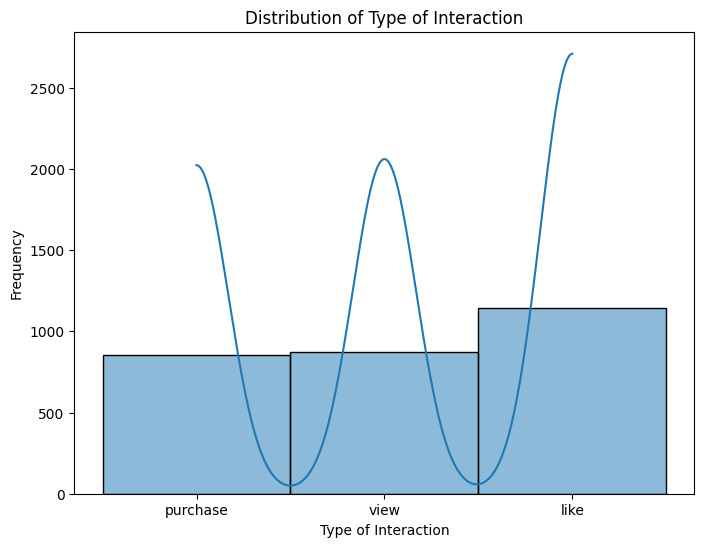

In [7]:
plt.figure(figsize=(8, 6))
sns.histplot(data=sales_customer_product, x="Age", kde=True)
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.figure(figsize=(8, 6))
sns.countplot(data=sales_customer_product, x="Gender")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.figure(figsize=(8, 6))
sns.histplot(data=sales_customer_product, x="Purchase Amount (USD)", kde=True)
plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Frequency")

plt.figure(figsize=(8, 6))
sns.countplot(data=sales_customer_product, x="Location")
plt.title("Location Distribution")
plt.xlabel("Location")
plt.ylabel("Count")
plt.xticks(rotation=90)

plt.figure(figsize=(8, 6))
sns.countplot(data=sales_customer_product, x="Category_x")
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.figure(figsize=(8, 6))
sns.histplot(data=sales_customer_product, x="Review Rating", kde=True)
plt.title("Distribution of Review Rating")
plt.xlabel("Review Rating")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.figure(figsize=(8, 6))
sns.countplot(data=sales_customer_product, x="Subscription Status")
plt.title("Subscription Status Distribution")
plt.xlabel("Subscription Status")
plt.ylabel("Count")

plt.figure(figsize=(8, 6))
sns.countplot(data=sales_customer_product, x="Shipping Type")
plt.title("Shipping Type Distribution")
plt.xlabel("Shipping Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.figure(figsize=(8, 6))
sns.countplot(data=sales_customer_product, x="Discount Applied")
plt.title("Discount Applied Distribution")
plt.xlabel("Discount Applied")
plt.ylabel("Count")

plt.figure(figsize=(8, 6))
sns.countplot(data=sales_customer_product, x="Promo Code Used")
plt.title("Promo Code Used Distribution")
plt.xlabel("Promo Code Used")
plt.ylabel("Count")

plt.figure(figsize=(8, 6))
sns.countplot(data=sales_customer_product, x="Payment Method")
plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.figure(figsize=(8, 6))
sns.countplot(data=sales_customer_product, x="Frequency of Purchases")
plt.title("Frequency of Purchases Distribution")
plt.xlabel("Frequency of Purchases")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.figure(figsize=(8, 6))
# sales_data['Interaction type'].value_counts().plot(kind='bar', color='purple')
sns.histplot(data=sales_customer_product, x="Interaction type", kde=True)
plt.title('Distribution of Type of Interaction')
plt.xlabel('Type of Interaction')
plt.ylabel('Frequency')

plt.show()


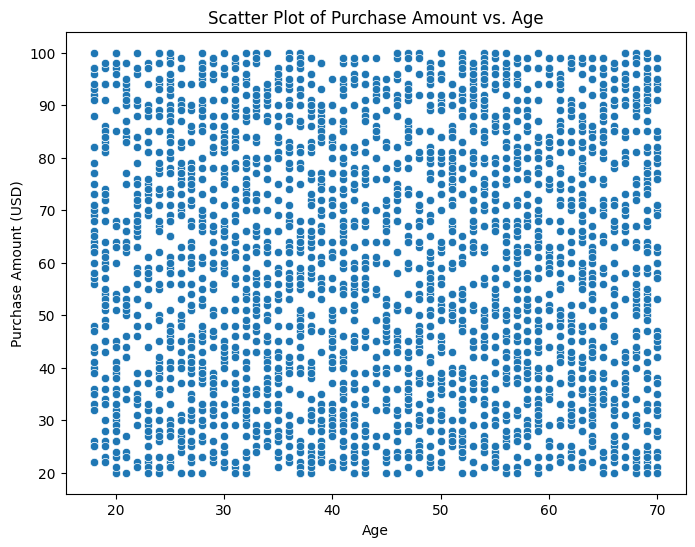

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=sales_customer_product, x="Age", y="Purchase Amount (USD)")
plt.title("Scatter Plot of Purchase Amount vs. Age")
plt.xlabel("Age")
plt.ylabel("Purchase Amount (USD)")
plt.show()


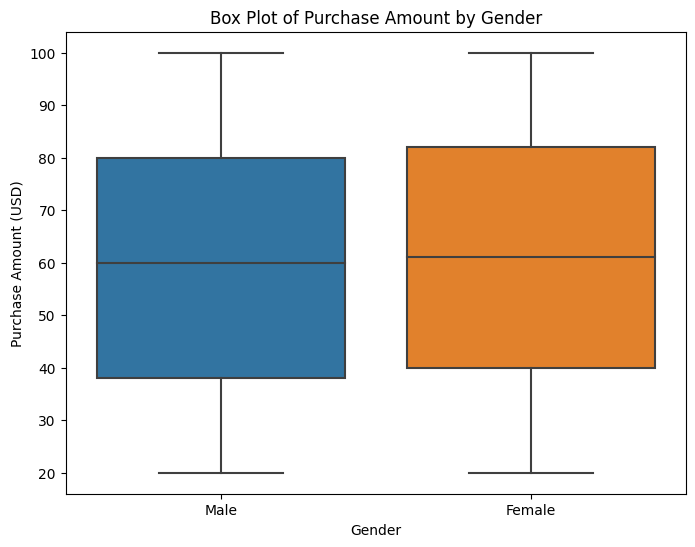

In [9]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=sales_customer_product, x="Gender", y="Purchase Amount (USD)")
plt.title("Box Plot of Purchase Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Purchase Amount (USD)")
plt.show()


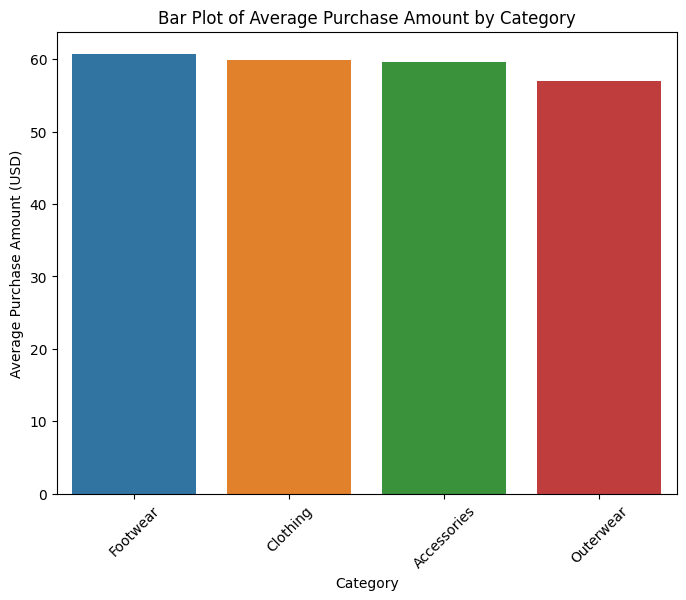

In [10]:
plt.figure(figsize=(8, 6))
# Group the data by category and calculate the average purchase amount
avg_purchase_by_category = sales_customer_product.groupby("Category_x")["Purchase Amount (USD)"].mean()

# Sort the categories by average purchase amount
avg_purchase_by_category = avg_purchase_by_category.sort_values(ascending=False)

# Convert the Series to a DataFrame
avg_purchase_by_category_df = avg_purchase_by_category.reset_index()

# Create a bar plot of the average purchase amount by category
sns.barplot(data=avg_purchase_by_category_df, x="Category_x", y="Purchase Amount (USD)")
plt.title("Bar Plot of Average Purchase Amount by Category")
plt.xlabel("Category")
plt.ylabel("Average Purchase Amount (USD)")
plt.xticks(rotation=45)
plt.show()
